In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import SimpleExpSmoothing
from sklearn.linear_model import LinearRegression

In [5]:
data = {
    'Month': np.arange(1, 13),
    'Sales': [5384, 8081, 10282, 9156, 6118, 9139, 12460, 10717, 7825, 9693, 15177, 10990]
}
df = pd.DataFrame(data)
df

,Month,Sales
0,1,5384
1,2,8081
2,3,10282
3,4,9156
4,5,6118
5,6,9139
6,7,12460
7,8,10717
8,9,7825
9,10,9693


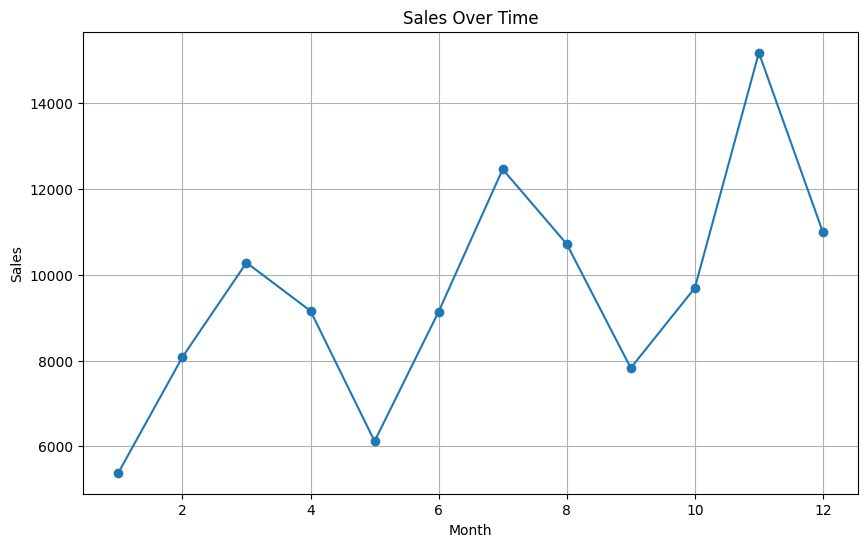

In [3]:
plt.figure(figsize=(10,6))
plt.plot(df['Month'], df['Sales'], marker='o')
plt.title('Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [6]:
moving_avg_forecasts = []
window = 3
df_temp = df.copy()

for i in range(13, 17):
    avg = df_temp['Sales'].iloc[-window:].mean()
    moving_avg_forecasts.append(avg)
    df_temp = pd.concat([df_temp, pd.DataFrame({'Month': [i], 'Sales': [avg]})], ignore_index=True)

print("Moving Average Forecasts (Months 13-16):", moving_avg_forecasts)

Moving Average Forecasts (Months 13-16): [np.float64(11953.333333333334), np.float64(12706.77777777778), np.float64(11883.370370370372), np.float64(12181.160493827163)]


In [7]:
model = SimpleExpSmoothing(df['Sales']).fit(smoothing_level=0.2, optimized=False)
exp_smoothing_forecasts = model.forecast(4)

print("Exponential Smoothing Forecasts (Months 13-16):", list(exp_smoothing_forecasts))

Exponential Smoothing Forecasts (Months 13-16): [10317.82346919936, 10317.82346919936, 10317.82346919936, 10317.82346919936]


In [9]:
cycles = {
    'Cycle1': df.iloc[0:4]['Sales'].values,
    'Cycle2': df.iloc[4:8]['Sales'].values,
    'Cycle3': df.iloc[8:12]['Sales'].values
}
cycle_means = {cycle: np.mean(values) for cycle, values in cycles.items()}
print("Cycle Averages:", cycle_means)

Cycle Averages: {'Cycle1': np.float64(8225.75), 'Cycle2': np.float64(9608.5), 'Cycle3': np.float64(10921.25)}


In [11]:
seasonal_indices = []
for cycle, sales in cycles.items():
    mean_sales = cycle_means[cycle]
    for value in sales:
        seasonal_indices.append(value / mean_sales)

seasonal_indices = np.array(seasonal_indices).reshape(3, 4)
avg_seasonal_indices = seasonal_indices.mean(axis=0)
print("Average Seasonal Indices:", avg_seasonal_indices)

X = np.array([[1], [2], [3]])  # Cycle numbers
y = np.array(list(cycle_means.values()))

reg = LinearRegression().fit(X, y)
next_cycle_avg = reg.predict(np.array([[4]]))[0]
print("Predicted average sales for next cycle:", next_cycle_avg)

seasonal_forecasts = next_cycle_avg * avg_seasonal_indices
print("Seasonal Forecasts (Months 13-16):", seasonal_forecasts)


Average Seasonal Indices: [0.66925032 0.94035853 1.31214059 1.07825055]
Predicted average sales for next cycle: 12280.666666666664
Seasonal Forecasts (Months 13-16): [ 8218.84007466 11548.22970296 16113.96125534 13241.6356337 ]


#Evaluation

Since actual sales data for months 13-16 is not available, forecast errors cannot be computed.
In practice, forecast accuracy would be evaluated using metrics such as MAE or RMSE after real values are observed.
